In [14]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import time

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from torch import nn, optim

In [16]:
notebook_dir = Path.cwd()
h5_dirs_path = notebook_dir.parent / "h5"
h5_dirs = sorted(path for path in h5_dirs_path.iterdir() if path.is_dir())
h5_dir = h5_dirs[np.random.randint(0, len(h5_dirs))]
h5_files = sorted(path for path in h5_dir.iterdir() if path.is_file() and path.suffix == ".h5")

if not h5_files:
    raise FileNotFoundError(f"No files found in {h5_dir}")

h5_path = h5_files[np.random.randint(0, len(h5_files))]
print(f"Found {len(h5_files)} files in {h5_dir.name}")
print(f"Example file: {h5_path.name}")

Found 6 files in MC_EGAM7
Example file: user.amoranch.50640351._000005.output.h5


In [17]:
file = h5py.File(h5_path, 'r')
file["egammas"].dtype.names

('pt',
 'eta',
 'phi',
 'e',
 'cl_e',
 'cl_eta',
 'cl_phi',
 'cl_etaBE2',
 'cl_phiBE2',
 'charge',
 'maxEcell_energy',
 'maxEcell_time',
 'maxEcell_x',
 'maxEcell_y',
 'maxEcell_z',
 'Rhad',
 'Rhad1',
 'Reta',
 'Rphi',
 'weta1',
 'weta2',
 'f1',
 'f3',
 'fracs1',
 'wtots1',
 'DeltaE',
 'Eratio',
 'topoetcone20',
 'topoetcone40',
 'ptcone20',
 'ptvarcone20',
 'ptvarcone30',
 'DFCommonElectronsECIDSResult',
 'core57cellsEnergyCorrection',
 'z0',
 'd0',
 'sig_z0',
 'nTracks',
 'truthType',
 'truthOrigin',
 'maxEcell_gain',
 'passid_VeryLoose',
 'passid_Loose',
 'passid_Medium',
 'passid_Tight',
 'passiso_Loose_VarRad',
 'maxEcell_onlId')

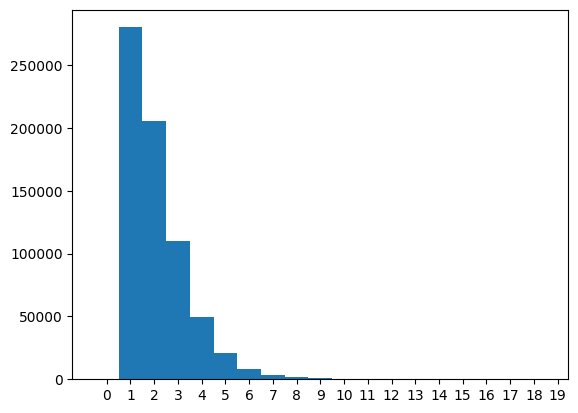

In [27]:
plt.hist(file["egammas"]["nTracks"], bins=np.arange(0, 20) - 0.5, density=False)
plt.xticks(range(20))
plt.show()

In [ ]:
class H5EgammaDataset_fully_batched(Dataset):
    #Initialization of the dataset class. Needs input for the dataset file paths, the source of the target variable, 
    #the field name of the target variable, and any fields to exclude from the features.
    def __init__(
        self,
        files,
        y_source="truth",
        y_field="pt",
        exclude_fields=None,
        exclude_features=None,
        include_fields=None,
        include_features=None,
    ):        
        if include_fields is not None and exclude_fields is not None:
            raise ValueError("Cannot specify both include_fields and exclude_fields.")
        if include_features is not None and exclude_features is not None:
            raise ValueError("Cannot specify both include_features and exclude_features.")
        
        self.files = [Path(path) for path in files]
        self.y_source = y_source
        self.y_field = y_field
        self.exclude_fields = set(exclude_fields or [])
        self.include_fields = set(include_fields) if include_fields is not None else None
        self.valid_rows = []
        self.handles = {}
        self.lengths = []
        self.fields = []



        example_file = self.files[0]
        with h5py.File(example_file, "r") as h5_file:
            feature_names = list(h5_file.keys())
            feature_names.remove("eventwise") if "eventwise" in h5_file else None
            if self.y_source not in feature_names:
                raise KeyError(f"Unknown y source: {self.y_source}")
            feature_names.remove("truth") if "truth" in h5_file else None

            if include_features is not None:
                feature_names = [name for name in feature_names if name in include_features]

            self.features = [name for name in feature_names if name not in exclude_features] if exclude_features != None else feature_names

            for feature in self.features:
                field_names = self._selected_field_names(feature, h5_file[feature].dtype.names)
                
                shape = h5_file[feature][0].shape
                if len(shape) > 1:
                    raise ValueError(f"Feature {feature} has shape {shape}, expected 1D-like structured array")
                elif len(shape) == 0:
                    self.fields.extend([f"{feature}_{name}" for name in field_names])
                else:
                    for i in range(shape[0]):
                        self.fields.extend([f"{feature}_{name}_{i}" for name in field_names])
                    
            field_names = self._selected_field_names(
                "eventwise", h5_file["eventwise"].dtype.names
            )
            self.fields.extend([f"eventwise_{name}" for name in field_names])

        #Finds the finite-target rows and creates offsets over the filtered dataset.
        for path in self.files:
            with h5py.File(path, "r") as h5_file:
                lengths = {
                    name: len(h5_file[name])
                    for name in feature_names
                }
                if len(set(lengths.values())) != 1:
                    raise ValueError(f"Event data not aligned in {path}")
                target = np.asarray(h5_file[self.y_source][self.y_field][:])
                valid_rows = np.flatnonzero(np.isfinite(target))
                self.lengths.append(len(valid_rows))
                self.valid_rows.append(valid_rows)

        self.offsets = np.concatenate(([0], np.cumsum(self.lengths)))

    #Finds the total length of the dataset by summing the lengths of all files. (Cumsum has already been calculated)
    def __len__(self):
        return int(self.offsets[-1])

    #Finds the file and row index corresponding to a given global index across all files.
    def _get_file_and_row(self, index):
        file_index = np.searchsorted(self.offsets, index, side="right") - 1
        filtered_index = int(index - self.offsets[file_index])
        local_index = int(self.valid_rows[file_index][filtered_index])
        if file_index not in self.handles:
            self.handles[file_index] = h5py.File(self.files[file_index], "r")
        return file_index, self.handles[file_index], local_index

    def _selected_field_names(self, dataset_name, field_names):
        excluded = set(self.exclude_fields)
        if dataset_name == self.y_source:
            excluded.add(self.y_field)

        if self.include_fields is not None:
            return [name for name in field_names if name in self.include_fields and name not in excluded]
        return [name for name in field_names if name not in excluded]

    #Converts a structured row to a flat array using the same field selection as the header.
    def _structured_to_array(self, rows, dataset_name):
        names = self._selected_field_names(dataset_name, rows.dtype.names)
        values = [np.asarray(rows[name], dtype=np.float32).reshape(-1) for name in names]
        return np.concatenate(values) if values else np.empty(0, dtype=np.float32)

    #Tries to read aligned rows in few contiguous slices if possible, otherwise reads them individually. Returns the rows and the sort order of the indices.
    def _read_aligned_rows(self, h5_file, indices):
        indices = np.asarray(indices, dtype=np.int64)
        sort_order = np.argsort(indices)
        sorted_indices = indices[sort_order]
        runs = np.flatnonzero(np.diff(sorted_indices) > 1) + 1
        run_starts = np.r_[0, runs]
        run_ends = np.r_[runs, len(sorted_indices)]
        use_slices = len(run_starts) <= max(1, len(sorted_indices) // 2)

        #Reverts to reading individual rows if the number of contiguous slices is too high, otherwise reads them in slices.
        if not use_slices:
            if self.y_source == "eventwise":
                return {name: h5_file[name][sorted_indices] for name in self.features}, [None]*len(sorted_indices), sort_order
            return {name: h5_file[name][sorted_indices] for name in self.features}, h5_file[self.y_source][self.y_field][sorted_indices], sort_order

        #This part takes care of the contigous reads. Reading a batch of 32 rows in one go reduces computation from 8s to 0.2s
        rows = {name: [] for name in self.features}
        target = []
        for start, end in zip(run_starts, run_ends):
            first = int(sorted_indices[start])
            last = int(sorted_indices[end - 1]) + 1
            relative_indices = sorted_indices[start:end] - first
            for name in self.features:
                rows[name].append(h5_file[name][first:last][relative_indices])
            if self.y_source != "eventwise":
                target.append(h5_file[self.y_source][self.y_field][first:last][relative_indices])
        if self.y_source == "eventwise":
            return {name: np.concatenate(rows[name]) for name in self.features}, [None]*len(sorted_indices), sort_order
        return {name: np.concatenate(rows[name]) for name in self.features}, np.concatenate(target), sort_order

    #This function groups a single data row into a torch tensor of features and a torch tensor of the target variable. It can also read the h5 file if no data is set yet.
    def _read_one(self, h5_file, local_index, eventwise=None, first_indices=None, rows=None, target=None):
        
        if eventwise is None:
            eventwise = h5_file["eventwise"][:]
        eventwise_names = eventwise.dtype.names
        if first_indices is None:
            first_indices = eventwise[eventwise_names[1]] # The second field can both be egammaindex or muonindex

        event_index = int(np.searchsorted(first_indices, local_index, side="right") - 1)
        if event_index < 0 or local_index >= first_indices[event_index] + eventwise[eventwise_names[0]][event_index]:
            raise IndexError(f"Egamma row {local_index} is not covered by eventwise")

        if rows is None:
            rows = {name: h5_file[name][local_index] for name in self.features}

        feature_arrays = [
            self._structured_to_array(rows[name], name)
            for name in self.features
        ]

        feature_arrays.append(self._structured_to_array(eventwise[event_index], "eventwise"))
        features = np.concatenate(feature_arrays)
        
               
        if self.y_source not in h5_file:
            raise KeyError(f"Unknown y source: {self.y_source}")
        target_index = event_index if self.y_source == "eventwise" else local_index
        if target is None:
            target = np.float32(h5_file[self.y_source][self.y_field][target_index])
        return torch.from_numpy(features), torch.tensor(target)
    
    #Depreciated single row read function. Torch dataloader will call __getitems__ instead of this function.
    def __getitem__(self, index):
        _, h5_file, local_index = self._get_file_and_row(index)
        return self._read_one(h5_file, local_index)

    #Main read function for the fully batched dataset. It groups the indices by file, reads the aligned rows in batches, and returns a list of feature-target pairs.
    def __getitems__(self, indices):
        indices = list(indices)
        grouped = {}
        for output_position, index in enumerate(indices):
            file_index = int(np.searchsorted(self.offsets, index, side="right") - 1)
            filtered_index = int(index - self.offsets[file_index])
            local_index = int(self.valid_rows[file_index][filtered_index])
            grouped.setdefault(file_index, []).append((output_position, local_index))

        if not hasattr(self, "eventwise_cache"):
            self.eventwise_cache = {}

        batch = [None] * len(indices)
        for file_index, positions in grouped.items():
            if file_index not in self.handles:
                self.handles[file_index] = h5py.File(self.files[file_index], "r")
            h5_file = self.handles[file_index]
            if file_index not in self.eventwise_cache:
                self.eventwise_cache[file_index] = h5_file["eventwise"][:]
            eventwise = self.eventwise_cache[file_index]
            local_indices = np.array([local_index for _, local_index in positions])
            rows, target, sort_order = self._read_aligned_rows(h5_file, local_indices)
            sorted_indices = np.sort(local_indices)
            first_indices = eventwise[eventwise.dtype.names[1]]

            for sorted_position, original_position in enumerate(np.argsort(sort_order)):
                batch[positions[original_position][0]] = self._read_one(
                    h5_file,
                    int(sorted_indices[sorted_position]),
                    eventwise,
                    first_indices,
                    {name: rows[name][sorted_position] for name in rows},
                    target[sorted_position],
                )

        return batch
    
    #Closes all open file handles and clears the handles dictionary to free up resources.
    def close(self):
        for handle in self.handles.values():
            handle.close()
        self.handles.clear()

class ShuffledContiguousBatchSampler(Sampler):
    #Initializes the sampler with the dataset size and batch size. It will create batches of contiguous indices and shuffle them for each epoch.
    def __init__(self, dataset_size, batch_size):
        self.dataset_size = dataset_size
        self.batch_size = batch_size

    #This function generates batches of contiguous indices, shuffles the starting indices of the batches, and yields the indices for each batch.
    def __iter__(self):
        starts = np.arange(0, self.dataset_size, self.batch_size)
        np.random.shuffle(starts)

        for start in starts:
            stop = min(start + self
                       .batch_size, self.dataset_size)
            yield list(range(start, stop))

    def __len__(self):
        return (self.dataset_size + self.batch_size - 1) // self.batch_size

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(NeuralNetwork, self).__init__()
        layers = []
        last_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(torch.nn.Linear(last_size, hidden_size))
            layers.append(torch.nn.ReLU())
            last_size = hidden_size
        layers.append(torch.nn.Linear(last_size, output_size))
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [45]:
def train_model(model, optimizer, loss_function, train_loader, val_loader, num_epochs=10, device='cpu', means=None, stds=None):
    model.to(device)
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    means = means.to(device) if means is not None else None
    stds = stds.to(device) if stds is not None else None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            if not torch.isfinite(targets).all():
                raise ValueError(f"Warning: Non-finite values detected in targets")
            if means is not None and stds is not None:
                inputs = (inputs - means) / stds  # Normalize inputs using provided means and stds
            elif means is not None or stds is not None:
                raise ValueError("Both means and stds must be provided for normalization.")
            inputs = torch.nan_to_num(inputs, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN values with 0.0

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            print(f'Batch {batch+1}/{len(train_loader)}, Loss: {loss.item():.4f}', end='\r')

        epoch_loss = running_loss / len(train_loader.dataset)

        val_loss = validate_model(model, loss_function, val_loader, device, means, stds)
        val_losses.append(val_loss)
        train_losses.append(epoch_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.4f}')

        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

    # Load the best model state before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, val_losses, train_losses


def validate_model(model, loss_function, val_loader, device='cpu', means=None, stds=None):
        # Validation phase
        model.eval()
        val_loss = 0.0
        means = means.to(device) if means is not None else None
        stds = stds.to(device) if stds is not None else None
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                if not torch.isfinite(targets).all():
                    raise ValueError(f"Warning: Non-finite values detected in targets")
                if means is not None and stds is not None:
                    inputs = (inputs - means) / stds  # Normalize inputs using provided means and stds
                elif means is not None or stds is not None:
                    raise ValueError("Both means and stds must be provided for normalization.")
                inputs = torch.nan_to_num(inputs, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN values with 0.0

                outputs = model(inputs)
                loss = loss_function(outputs.squeeze(), targets)
                val_loss += loss.item() * inputs.size(0)

        val_loss /= len(val_loader.dataset)
        return val_loss

def predict_model(model, test_loader, device='cpu', means=None, stds=None):
    model.eval()
    predictions = []
    means = means.to(device) if means is not None else None
    stds = stds.to(device) if stds is not None else None
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            
            if means is not None and stds is not None:
                inputs = (inputs - means) / stds  # Normalize inputs using provided means and stds
            elif means is not None or stds is not None:
                raise ValueError("Both means and stds must be provided for normalization.")
            inputs = torch.nan_to_num(inputs, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN values with 0.0

            outputs = model(inputs)
            predictions.append(outputs.cpu().numpy())
        print("Prediction completed")
        print(f"Predictions shape: {[p.shape for p in predictions]}")
    return np.concatenate(predictions)

In [9]:
exclude_features = []
exclude_fields = ["pt"]

train_dataset = H5EgammaDataset_fully_batched(
    files=h5_files,
    y_source="muons",
    y_field="pt",
    exclude_fields=exclude_fields,
    exclude_features=exclude_features
)
val_dataset = H5EgammaDataset_fully_batched(
    files=[h5_files[-1]],
    y_source="muons",
    y_field="pt",
    exclude_fields=exclude_fields,
    exclude_features=exclude_features
)

In [43]:
sample_limit = 100_000
file = h5py.File(h5_path, "r")
dataset_names = ["egammas", "cells", "tracks", "eventwise"]

means = {dataset_name: {} for dataset_name in dataset_names if dataset_name not in exclude_features}
stds = {dataset_name: {} for dataset_name in dataset_names if dataset_name not in exclude_features}

for dataset_name in dataset_names:
    if dataset_name in exclude_features:
        continue
    dataset = file[dataset_name]
    sample = dataset[:min(sample_limit, len(dataset))]

    for field_name in dataset.dtype.names:
        values = np.asarray(sample[field_name], dtype=np.float64)

        field_mean = np.nanmean(values, axis=0)
        field_std = np.nanstd(values, axis=0)

        field_std = np.where(
            np.isfinite(field_std) & (field_std > 0),
            field_std,
            1.0,
        )

        means[dataset_name][field_name] = (
            np.asarray(field_mean).reshape(-1).astype(np.float32)
        )
        stds[dataset_name][field_name] = (
            np.asarray(field_std).reshape(-1).astype(np.float32)
        )

In [44]:
arr_means = []
arr_stds = []

for dataset_name in train_dataset.features + ["eventwise"]:
    for field_name in file[dataset_name].dtype.names:
        if field_name not in train_dataset.exclude_fields:
            arr_means.extend(means[dataset_name][field_name])
            arr_stds.extend(stds[dataset_name][field_name])

arr_means = torch.tensor(arr_means, dtype=torch.float32)
arr_stds = torch.tensor(arr_stds, dtype=torch.float32)

sample_features, _ = train_dataset[0]

if arr_means.numel() != sample_features.numel():
    raise ValueError(
        f"Statistics have {arr_means.numel()} values, "
        f"but samples have {sample_features.numel()} features"
    )

if arr_stds.shape != arr_means.shape:
    raise ValueError("arr_means and arr_stds have different shapes")

if not torch.isfinite(arr_stds).all() or (arr_stds == 0).any():
    raise ValueError("arr_stds contains zero or non-finite values")

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = NeuralNetwork(input_size=train_dataset[0][0].shape[0], hidden_sizes=[128, 64], output_size=1)
model.to(device)
train_sampler = ShuffledContiguousBatchSampler(len(train_dataset), batch_size=1024)
#val_sampler = ShuffledContiguousBatchSampler(len(val_dataset), batch_size=1024)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.MSELoss()

sample_features, _ = train_dataset[0]
train_dataset.close()
val_dataset.close()
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=0)

In [45]:
model, val_losses, train_losses = train_model(model, optimizer, loss_function, train_loader, val_loader, num_epochs=5, device=device, means=arr_means, stds=arr_stds)

Epoch 1/5, Training Loss: 103296093502.2595, Validation Loss: 90458217.1626
Epoch 2/5, Training Loss: 108484727728.7945, Validation Loss: 241229420.1660
Epoch 3/5, Training Loss: 14194226608.4389, Validation Loss: 86620220.2242
Epoch 4/5, Training Loss: 2525507455.5030, Validation Loss: 45062172.6830
Epoch 5/5, Training Loss: 632237157.1014, Validation Loss: 34551145.8739


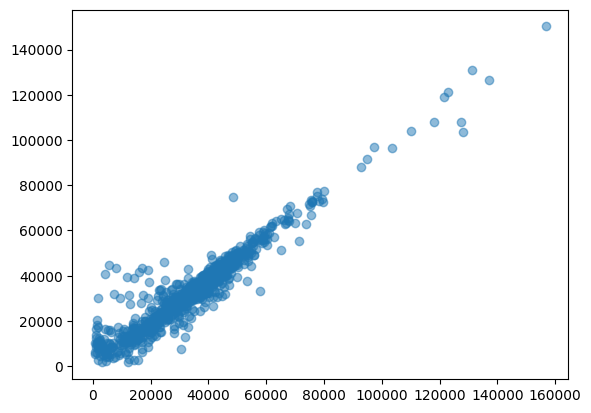

In [48]:
x, y = next(iter(train_loader))
x_mod = (x.to(device) - arr_means.to(device)) / arr_stds.to(device)
x_mod = torch.nan_to_num(x_mod, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN values with 0.0
y_ = model(x_mod).cpu().detach().numpy()
plt.plot(y.numpy(), y_, 'o', alpha=0.5)